# 6차시 실습 — 그래프로 공정 상태 이해하기 (정답)

교육용 가상 데이터(180행, 설비 4대)로 그래프 다섯 가지를 그립니다.

## 1단계. 데이터 준비하기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 글꼴(Windows)
plt.rcParams["axes.unicode_minus"] = False      # 음수 부호 깨짐 방지

df = pd.read_csv("../../data/weekly/week06/week06_process_visualization.csv", encoding="utf-8-sig")
df.head()

,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,두께_nm,진동_mm_s,처리시간_sec,합격여부
0,2024-03-01 05:00,LOT-0472,EQ-04,식각,295.6,1026.3,97.35,0.507,124.3,-1
1,2024-03-01 17:00,LOT-0206,EQ-04,증착,301.6,1008.5,99.79,0.487,123.5,1
2,2024-03-01 19:00,LOT-0403,EQ-04,포토,300.8,1006.1,99.34,0.501,114.9,1
3,2024-03-02 00:00,LOT-0468,EQ-01,식각,297.8,1010.0,95.23,0.467,117.0,1
4,2024-03-02 03:00,LOT-0117,EQ-01,산화,299.5,1014.7,100.53,0.544,115.2,1


### 측정시간을 날짜로 바꾸기

In [2]:
df["측정시간"] = pd.to_datetime(df["측정시간"])
df["측정시간"].head(3)

0   2024-03-01 05:00:00
1   2024-03-01 17:00:00
2   2024-03-01 19:00:00
Name: 측정시간, dtype: datetime64[us]

## 2단계. 선 그래프 — 시간에 따른 온도

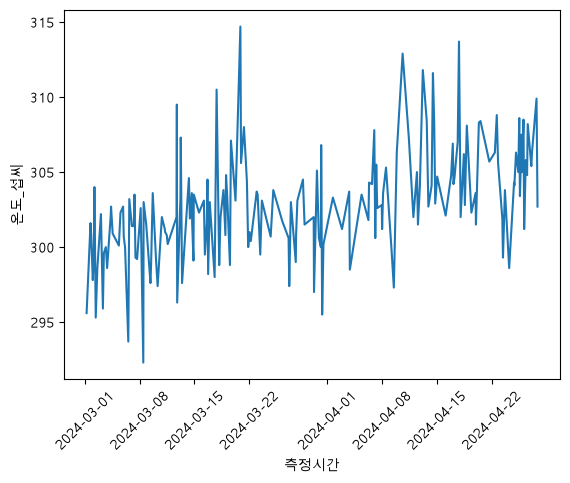

In [3]:
plt.plot(df["측정시간"], df["온도_섭씨"])
plt.xticks(rotation=45)   # 날짜 글자를 45도 기울여 겹치지 않게
plt.xlabel("측정시간")
plt.ylabel("온도_섭씨")
plt.show()

## 3단계. 막대그래프 — 설비별 기록 건수

In [4]:
counts = df["설비번호"].value_counts()
print(counts)

설비번호
EQ-04    50
EQ-01    47
EQ-03    46
EQ-02    37
Name: count, dtype: int64


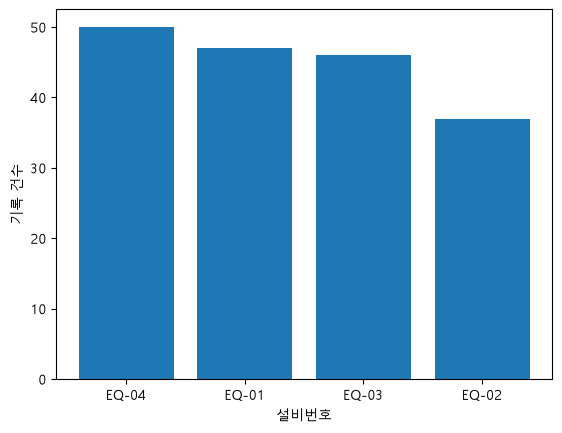

In [5]:
plt.bar(counts.index, counts)
plt.xlabel("설비번호")
plt.ylabel("기록 건수")
plt.show()

## 4단계. 히스토그램 — 온도가 몰린 구간

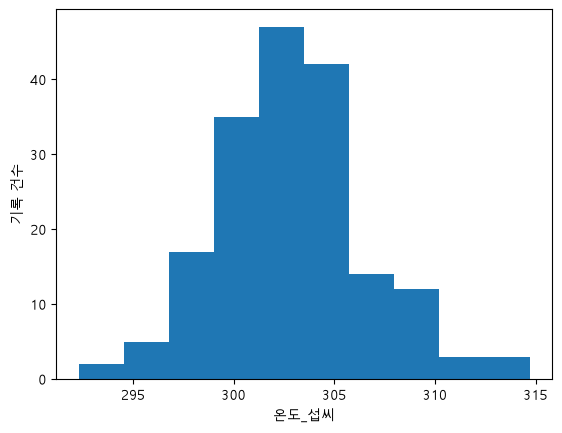

In [6]:
plt.hist(df["온도_섭씨"], bins=10)
plt.xlabel("온도_섭씨")
plt.ylabel("기록 건수")
plt.show()

## 5단계. 산점도 — 온도와 두께를 함께 보기

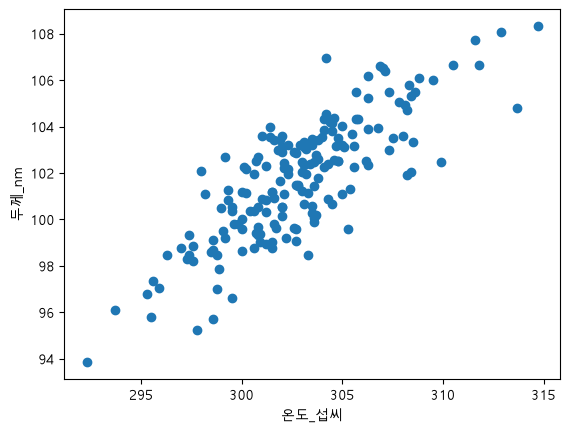

In [7]:
plt.scatter(df["온도_섭씨"], df["두께_nm"])
plt.xlabel("온도_섭씨")
plt.ylabel("두께_nm")
plt.show()

### 직접 해보기 — 온도와 압력도 함께 움직일까?

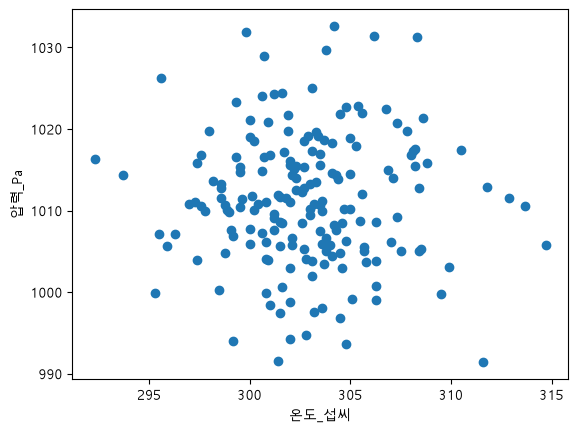

In [8]:
plt.scatter(df["온도_섭씨"], df["압력_Pa"])
plt.xlabel("온도_섭씨")
plt.ylabel("압력_Pa")
plt.show()

## 6단계. 박스플롯 — 설비별 온도 퍼짐

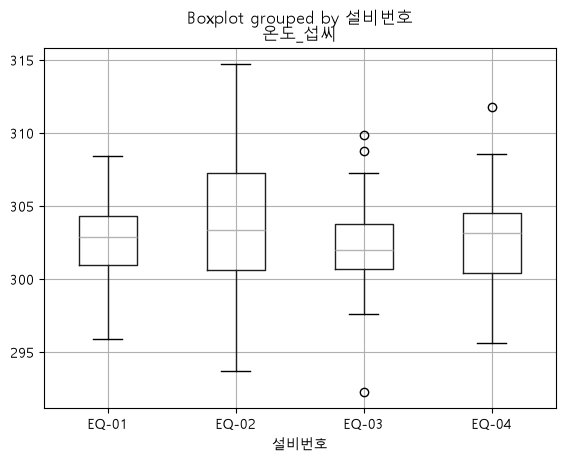

In [9]:
df.boxplot(column="온도_섭씨", by="설비번호")
plt.show()

## 7단계. 숫자로 다시 확인하고 한 문장으로 정리하기

In [10]:
print(df.groupby("설비번호")["온도_섭씨"].describe().round(1))

       count   mean  std    min    25%    50%    75%    max
설비번호                                                       
EQ-01   47.0  302.8  3.2  295.9  301.0  302.9  304.4  308.4
EQ-02   37.0  303.7  5.4  293.7  300.6  303.4  307.3  314.7
EQ-03   46.0  302.2  3.1  292.3  300.7  302.0  303.8  309.9
EQ-04   50.0  302.7  3.0  295.6  300.4  303.2  304.5  311.8


**해석 예시**: 네 설비의 평균 온도는 302.2~303.7℃로 비슷하지만, EQ-02는 상자 폭(25%~75%)이 300.6~307.3℃로
가장 넓어 온도가 가장 들쭉날쭉하다. 평균만 봤다면 놓쳤을 차이다.

### 도전 문제 — 설비별 진동 박스플롯 (빠른 학습자용)

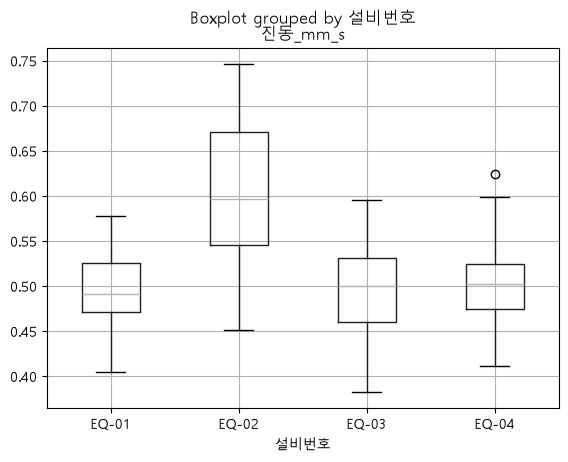

In [11]:
df.boxplot(column="진동_mm_s", by="설비번호")
plt.show()

**예시**: EQ-02의 진동 상자는 다른 설비보다 위쪽에 있고 길이도 길다. 온도와 진동 모두 EQ-02가 튀므로
EQ-02를 먼저 더 살펴볼 만하다. 무엇 때문에 그런지는 그래프만으로 단정할 수 없다.

## 8단계. AI에게 질문하며 더 알아보기
질문 예시는 강의 "AI로 한 걸음 더" 절에 있습니다. 답은 학생마다 다릅니다.

## 9단계. AI에게 코드 생성 요청하고 직접 실행해보기
강의의 "AI가 만들어줄 수 있는 코드 예시"입니다.

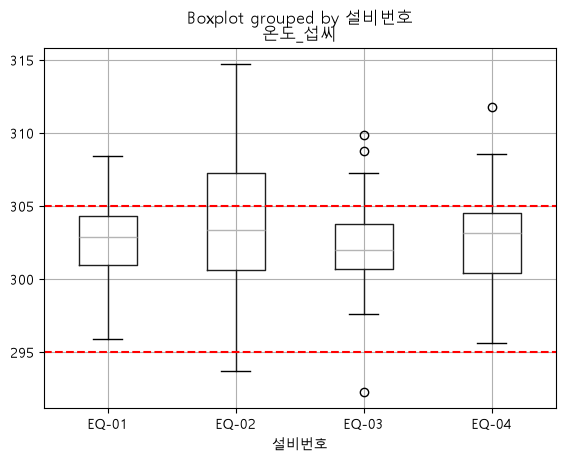

In [12]:
df.boxplot(column="온도_섭씨", by="설비번호")
plt.axhline(295, color="red", linestyle="--")   # 정상 범위 아래 끝
plt.axhline(305, color="red", linestyle="--")   # 정상 범위 위 끝
plt.show()

## 10단계. 연습문제 — 불합격 기록을 설비별 막대그래프로

In [13]:
fails = df[df["합격여부"] == -1]   # -1 = 불합격
fail_counts = fails["설비번호"].value_counts()
print(fail_counts)

설비번호
EQ-04    8
EQ-02    8
EQ-03    3
EQ-01    2
Name: count, dtype: int64


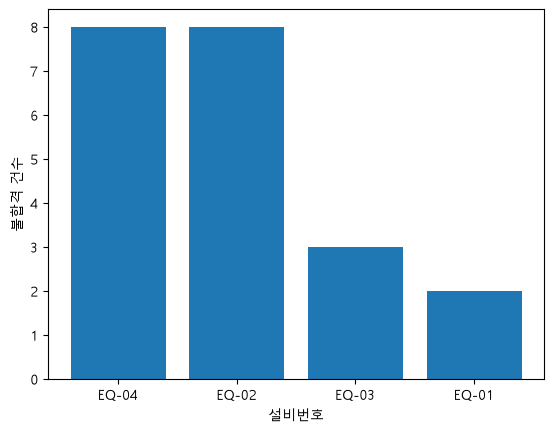

In [14]:
plt.bar(fail_counts.index, fail_counts)
plt.xlabel("설비번호")
plt.ylabel("불합격 건수")
plt.show()

## 11단계. AI로 재미있는 미니 프로그램 만들기
강의 예시 코드입니다. 숫자는 10단계에서 센 설비별 불합격 건수입니다.

In [15]:
fail_dict = {"EQ-01": 2, "EQ-02": 8, "EQ-03": 3, "EQ-04": 8}

print("설비별 불합격 건수 (글자 막대그래프)")
for name, count in fail_dict.items():
    bar = "■" * count
    print(f"{name}: {bar} {count}")

설비별 불합격 건수 (글자 막대그래프)
EQ-01: ■■ 2
EQ-02: ■■■■■■■■ 8
EQ-03: ■■■ 3
EQ-04: ■■■■■■■■ 8
